<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/colab_A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane
!pip install scikit-learn

# 1 - Importar Bibliotecas

In [ ]:
from pennylane import numpy as np
import pennylane as qml

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans

# 2 - Feature Map

Um feature map é o mapeamento dos dados clássicos $\mathbb{x}$ para um estado quântico $| \phi (\mathbb{x}) \rangle$, permitindo que o circuito quântico processe a informação. Aqui, vamos utilizar o **Angle Encoding**

$\mathbb{x} → | \phi(\mathbb{x}) \rangle = S(\mathbb{x})|0 \rangle, $

onde $S(\mathbb{x})$ é o circuito que encoda $\mathbf{x}$ nos qubits, sendo formado por respectivas rotações nos qubits.

Para entender melhor, vamos ver um exemplo:

Considere um vetor de dados clássico com duas componentes,

$$
\mathbf{x} = (x_1, x_2).
$$

No *Angle Encoding*, cada componente de $\mathbf{x}$ é codificada como um
ângulo de rotação em um qubit. O *feature map* é definido por

$$
S(\mathbf{x}) = R_X(x_1) \otimes R_X(x_2),
$$

onde $R_X(\theta) = e^{-i \theta \sigma_x / 2}$.

Aplicando o circuito ao estado inicial $|00\rangle$, obtemos o estado quântico

$$
|\phi(\mathbf{x})\rangle
= S(\mathbf{x}) |00\rangle
= R_X(x_1)|0\rangle \otimes R_X(x_2)|0\rangle.
$$

Explicitamente,

$$
|\phi(\mathbf{x})\rangle
=
\left(\cos\frac{x_1}{2}|0\rangle - i \sin\frac{x_1}{2}|1\rangle\right)
\otimes
\left(\cos\frac{x_2}{2}|0\rangle - i \sin\frac{x_2}{2}|1\rangle\right),
$$
ou seja, a informação clássica está encodada por ângulos de rotação nos qubits.

Agora, vamos ver como implementar usando a pennylane:





In [ ]:
# Número de qubits (igual à dimensão do vetor de dados x)
n = 3

# --------------------------------------------------
# Feature map via Angle Encoding
# --------------------------------------------------
# Esta função implementa o mapeamento dos dados clássicos
# x = (x_1, x_2, x_3) para um estado quântico |φ(x)⟩.
#
# Cada componente x_i é codificada como um ângulo de rotação
# em torno do eixo X no qubit i, partindo do estado inicial |0⟩.
#
# Matematicamente:
#   |φ(x)⟩ = S(x) |000⟩
#   S(x) = ⊗_{i=1}^3 R_X(x_i)
#
def S(x):
    qml.AngleEmbedding(x, wires=range(n), rotation='X')

# --------------------------------------------------
# Dispositivo quântico (simulador)
# --------------------------------------------------
# Utilizamos o simulador default.qubit com n qubits,
# todos inicializados no estado |0⟩.
dev = qml.device('default.qubit', wires=n)

# --------------------------------------------------
# Circuito quântico
# --------------------------------------------------
# O QNode define o circuito variacional que aplica
# o feature map S(x) ao estado inicial |000⟩.
#
# A saída do circuito é o estado quântico completo |φ(x)⟩,
# retornado no espaço de Hilbert de dimensão 2^n.
#
@qml.qnode(dev)
def circuit(x):
    S(x)   # aplica o feature map
    return qml.state() # retorna o estado |φ(x)⟩


In [ ]:
x = [0, 10, 2]

In [ ]:
print(qml.draw(circuit, level="device")(x))

0: ──RX(0.00)──┤ ╭State
1: ──RX(10.00)─┤ ├State
2: ──RX(2.00)──┤ ╰State


# 2 - Algoritmos Supervisionados


## 2.1 - QKNN

O QKNN segue a mesma lógica do KNN clássico, mas mede proximidade via
**similaridade quântica** entre estados codificados. Por exemplo, dado um ponto
de teste $\mathbf{x}$ e um ponto do treino $\mathbf{x}^{(i)}$, codificamos:

$$
|\phi(\mathbf{x})\rangle = S(\mathbf{x})|0\rangle,
\qquad
|\phi(\mathbf{x}^{(i)})\rangle = S(\mathbf{x}^{(i)})|0\rangle.
$$

Uma medida simples de “proximidade” é a fidelidade (overlap):

$$
\text{sim}\!\left(\mathbf{x},\mathbf{x}^{(i)}\right)
= \left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{x}^{(i)}) \rangle\right|^2.
$$

Então, o QKNN escolhe os $k$ pontos de treino com maior similaridade
(ou menor distância equivalente), e decide o rótulo por votação (aquele que se repete mais vezes):

$$
\hat{y}(\mathbf{x})
=
\operatorname{mode}\Big(\, y_{(1)}, y_{(2)}, \dots, y_{(k)} \Big),
$$

onde $(1),(2),\dots,(k)$ são os índices dos $k$ vizinhos mais próximos no espaço quântico.

### 2.1.1 - Data Loading
Utilizamos o conjunto de dados Iris para ilustrar um exemplo simples de
classificação binária em aprendizado de máquina quântico. Selecionamos
apenas duas características por amostra, de modo que cada dado clássico
possa ser codificado diretamente em dois qubits por meio de *Angle Encoding*.

Para simplificar o problema, consideramos apenas as classes 0 e 1 do Iris,
obtendo um cenário de classificação binária. Os dados são então normalizados
para o intervalo $[0,\pi]$, garantindo compatibilidade com os ângulos de
rotação utilizados no circuito quântico.

Por fim, o conjunto de dados é dividido em um pequeno conjunto de treino
e um conjunto de teste. O conjunto de treino é mantido propositalmente
reduzido, refletindo um cenário típico de demonstração de algoritmos
quânticos variacionais e de métodos baseados em similaridade, como o QKNN.


In [ ]:
# --------------------------------------------------
# Carregamento do dataset Iris
# --------------------------------------------------
iris = load_iris()

# Selecionamos apenas as duas primeiras features
# (por exemplo, comprimento e largura da sépala),
# permitindo o uso direto de 2 qubits no feature map
X = iris.data[:, :2]

# Rótulos das classes
y = iris.target

# --------------------------------------------------
# Filtragem para classificação binária
# --------------------------------------------------
# Mantemos apenas as classes 0 e 1 do Iris,
# simplificando o problema para um caso binário
mask = y < 2
X = X[mask]
y = y[mask]

# --------------------------------------------------
# Normalização dos dados
# --------------------------------------------------
# Escalamos cada feature para o intervalo [0, pi],
# tornando os valores compatíveis com rotações quânticas
# no esquema de Angle Encoding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

# --------------------------------------------------
# Divisão em treino e teste
# --------------------------------------------------
# Selecionamos um conjunto de treino pequeno (10 amostras),
# adequado para demonstrações de QML e QKNN,
# e reservamos 25% dos dados para teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=15,
    test_size=0.10,
    random_state=0,
    stratify=y  # garante proporção equilibrada entre as classes
)


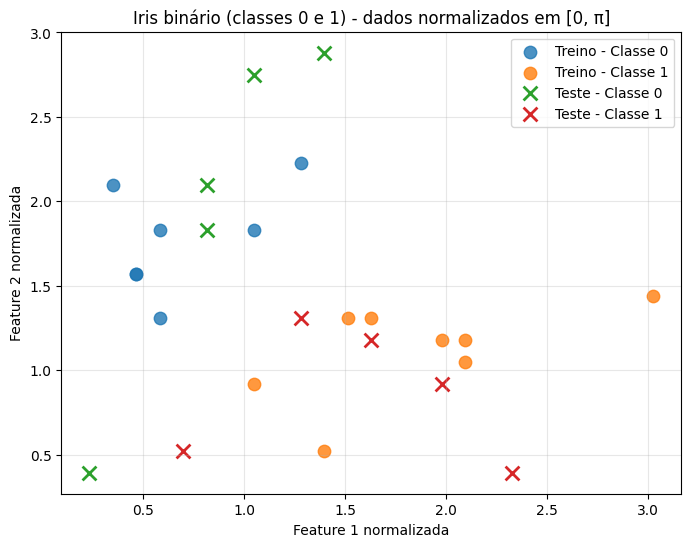

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Gráfico dos dados
# --------------------------------------------------
plt.figure(figsize=(8, 6))

# treino - classe 0
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Treino - Classe 0",
    marker="o",
    s=80,
    alpha=0.8
)

# treino - classe 1
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Treino - Classe 1",
    marker="o",
    s=80,
    alpha=0.8
)

# teste - classe 0
plt.scatter(
    X_test[y_test == 0, 0],
    X_test[y_test == 0, 1],
    label="Teste - Classe 0",
    marker="x",
    s=100,
    linewidths=2
)

# teste - classe 1
plt.scatter(
    X_test[y_test == 1, 0],
    X_test[y_test == 1, 1],
    label="Teste - Classe 1",
    marker="x",
    s=100,
    linewidths=2
)

plt.xlabel("Feature 1 normalizada")
plt.ylabel("Feature 2 normalizada")
plt.title("Iris binário (classes 0 e 1) - dados normalizados em [0, π]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2.1.2 - Criando a similaridades

Para comparar dois pontos de dados clássicos no QKNN, utilizamos uma medida
de similaridade definida no espaço quântico. Cada vetor clássico
$\mathbf{x}$ e $\mathbf{x^{(i)}}$ é codificado em estados quânticos
$|\phi(\mathbf{x})\rangle$ e $|\phi(\mathbf{y})\rangle$ por meio do mesmo
feature map $S(\cdot)$.

A similaridade entre os dois pontos é obtida a partir da fidelidade entre
os estados quânticos, definida como
$$
F(\mathbf{x}, \mathbf{x^{(i)}})
= \left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{x^{(i)}}) \rangle\right|^2.
$$

No circuito, essa fidelidade é estimada aplicando $S(\mathbf{x})$ seguido
do operador adjunto $S^\dagger(\mathbf{x^{(i)}})$ e medindo a probabilidade de
obter o estado $|0\ldots0\rangle$. A distância quântica é então definida
como
$$
d_q(\mathbf{x}, \mathbf{x^{(i)}}) = 1 - F(\mathbf{x}, \mathbf{x^{(i)}}),
$$
sendo pequena quando os estados são semelhantes e próxima de 1 quando são
distintos.


In [ ]:
# Número de qubits (igual à dimensão dos vetores de entrada)
n = 2

# Simulador quântico com n qubits, inicializados em |00⟩
dev = qml.device("default.qubit", wires=n)

# --------------------------------------------------
# Cálculo da fidelidade entre dois vetores clássicos
# --------------------------------------------------
# O circuito prepara o estado |φ(x)⟩ aplicando o feature map S(x),
# em seguida aplica o adjunto do feature map S†(y),
# e mede as probabilidades no espaço computacional.
#
# A probabilidade associada ao estado |00⟩ corresponde à fidelidade
# |⟨φ(x)|φ(xi)⟩|².
#
@qml.qnode(dev)
def fidelity(x, xi):
    S(x)                # prepara |φ(x)⟩
    qml.adjoint(S)(xi)   # aplica S†(y)
    probs = qml.probs(wires=range(n))
    return probs

# --------------------------------------------------
# Distância quântica baseada em fidelidade
# --------------------------------------------------
# Definimos a distância quântica como:
#   d_q(x, y) = 1 - F(x, y),
# onde F(x, y) é a fidelidade entre os estados quânticos.
#
# probs[0] é a probabilidade de medir |00⟩,
# que corresponde exatamente à fidelidade.
#
def quantum_distance(x, xi):
    return float(1.0 - fidelity(x, xi)[0])


### 2.1.3 - Rodando o algoritmo

Agora comparamos o KNN clássico com uma versão “quântica” baseada em
similaridade no espaço de Hilbert. Em ambos os casos, o algoritmo recebe
um conjunto de treino rotulado e, para cada ponto de teste, encontra os
$k$ vizinhos mais próximos e decide o rótulo por votação majoritária.

No KNN clássico, a proximidade é calculada diretamente no espaço original
dos dados (por exemplo, usando distância Euclidiana). No KNN quântico,
substituímos essa métrica por uma distância definida via circuito quântico,
calculada a partir da fidelidade entre estados codificados:
$$
d_q(\mathbf{x},\mathbf{x^{(i)}}) = 1 - \left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{x^{(i)}}) \rangle\right|^2.
$$

Por fim, treinamos ambos os modelos com o mesmo conjunto de treino e
avaliamos a acurácia no conjunto de teste.


In [ ]:
# Número de vizinhos a considerar no KNN
k = 3

# --------------------------------------------------
# KNN clássico
# --------------------------------------------------
# Usa a métrica padrão do scikit-learn (tipicamente distância Euclidiana)
# para medir proximidade no espaço original dos dados X.
knn_classic = KNeighborsClassifier(n_neighbors=k)

# --------------------------------------------------
# KNN "quântico"
# --------------------------------------------------
# Aqui substituímos a métrica padrão por quantum_distance,
# que calcula distância via fidelidade entre estados quânticos.
#
# algorithm="brute" é necessário porque estamos fornecendo
# uma métrica customizada (função Python), então o sklearn
# não consegue usar estruturas otimizadas como KD-tree.
knn_quantum = KNeighborsClassifier(
    n_neighbors=k,
    metric=quantum_distance,
    algorithm="brute"
)

# --------------------------------------------------
# Treino (fit)
# --------------------------------------------------
# O KNN "treina" basicamente armazenando os pontos do treino e seus rótulos.
knn_classic.fit(X_train, y_train)
knn_quantum.fit(X_train, y_train)

# --------------------------------------------------
# Predição (predict)
# --------------------------------------------------
# Para cada ponto de teste, encontra os k vizinhos mais próximos
# segundo a métrica escolhida e faz votação majoritária.
y_pred_classic = knn_classic.predict(X_test)
y_pred_quantum = knn_quantum.predict(X_test)

# --------------------------------------------------
# Avaliação
# --------------------------------------------------
# Comparamos a acurácia (fração de acertos) no conjunto de teste.
print("Acurácia clássica:", accuracy_score(y_test, y_pred_classic))
print("Acurácia quântica:", accuracy_score(y_test, y_pred_quantum))


Acurácia clássica: 0.9
Acurácia quântica: 0.9


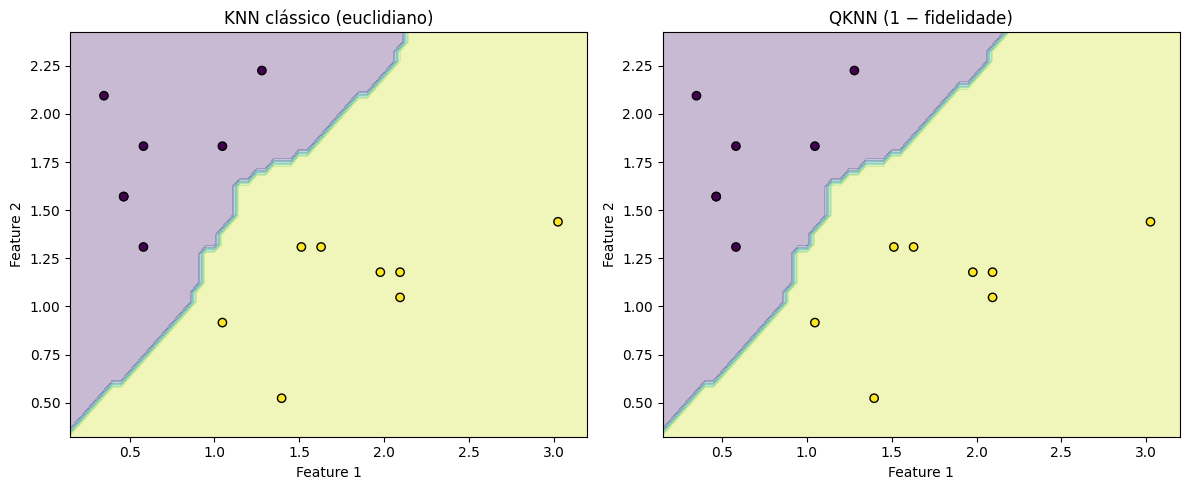

In [ ]:
def plot_decision_boundary(model, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(knn_classic, X_train, y_train, "KNN clássico (euclidiano)")
plt.subplot(1, 2, 2)
plot_decision_boundary(knn_quantum, X_train, y_train, "QKNN (1 − fidelidade)")

plt.tight_layout()
plt.show()



## 2.2 – QSVM

O **QSVM (Quantum Support Vector Machine)** é a versão quântica do SVM clássico,
na qual a separação entre classes é realizada **em um espaço de Hilbert induzido
por um kernel quântico**. Em vez de definir explicitamente uma transformação
não linear dos dados, o QSVM utiliza **estados quânticos codificados** para
definir implicitamente essa transformação.

Dado um vetor clássico $\mathbf{x}$, ele é codificado em um estado quântico por
meio de um *feature map* quântico:

$$
|\phi(\mathbf{x})\rangle = S(\mathbf{x})|0\ldots 0\rangle.
$$

A noção de similaridade entre dois pontos $\mathbf{x}$ e $\mathbf{x}^{(i)}$ é então
definida pela **fidelidade entre os estados quânticos correspondentes**, o que
leva à definição do kernel quântico:

$$
K(\mathbf{x}, \mathbf{x}^{(i)})
=
\left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{x}^{(i)}) \rangle\right|^2.
$$

Esse kernel mede o quão próximos dois pontos estão **no espaço quântico**, e
substitui diretamente kernels clássicos como o linear ou o RBF. A partir dele,
o SVM constrói um hiperplano de separação de margem máxima nesse espaço
implícito, resolvendo o problema clássico de otimização convexa do SVM, mas
utilizando uma matriz de kernel calculada por circuitos quânticos.

Diferentemente do QKNN, onde a decisão é feita por votação local entre vizinhos,
o QSVM é um método **global**, no qual a fronteira de decisão é determinada por
um subconjunto de pontos de treino (os *support vectors*) e pelo kernel
quântico que define a geometria do espaço de características.

### 2.2.1 - Feature map

Cada vetor clássico $\mathbf{x}$ é codificado em um estado
   quântico
   $$
   |\phi(\mathbf{x})\rangle = S(\mathbf{x})|0\ldots 0\rangle.
   $$

In [ ]:
# ----------------------------
# 1) Dataset Iris (2D, binário)
# ----------------------------
iris = load_iris()

# Seleciona duas features para usar dois qubits
X = iris.data[:, :2]
y = iris.target

# Mantém apenas classes 0 e 1
mask = y < 2
X = X[mask]
y = y[mask]

# Escala para [0, pi], adequado ao AngleEmbedding
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X = scaler.fit_transform(X)

# Divide em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=10, test_size=0.25, random_state=0, stratify=y
)

# ----------------------------
# 2) Feature map e kernel quântico
# ----------------------------
n = 2
dev = qml.device("default.qubit", wires=n)


@qml.qnode(dev)
def kernel_entry(x, xp):
    # Prepara |phi(x)>
    S(x)

    # Aplica S†(xp)
    qml.adjoint(S)(xp)

    # Probabilidade de |00> corresponde à fidelidade
    probs = qml.probs(wires=range(n))
    return probs

### 2.2.2 - Kernel quântico
A similaridade entre dois pontos é definida pela
   fidelidade entre os estados quânticos
   $$
   K(\mathbf{x}, \mathbf{x}^{(i)})
   = \left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{x}^{(i)}) \rangle\right|^2.
   $$

In [ ]:
def quantum_kernel_matrix(A, B):
    """Constrói a matriz de kernel K_{ij} = |<phi(A_i)|phi(B_j)>|^2."""
    K = np.zeros((len(A), len(B)), dtype=float)
    for i in range(len(A)):
        for j in range(len(B)):
            K[i, j] = float(kernel_entry(A[i], B[j])[0])
    return K

### 2.2.3 - Estimativa do kernel
O kernel é calculado aplicando $S(\mathbf{x})$ seguido de $S^\dagger(\mathbf{x}')$ e medindo a probabilidade de observar o estado $|0\ldots 0\rangle$.



In [ ]:
# ----------------------------
# 3) Treinamento do QSVM
# ----------------------------
K_train = quantum_kernel_matrix(X_train, X_train)
K_test  = quantum_kernel_matrix(X_test, X_train)

### 2.2.4 - SVM com kernel precomputado
A matriz de kernel é construída explicitamente e utilizada para treinar um classificador SVM clássico.


In [ ]:
qsvm = SVC(kernel="precomputed", C=1.0)
qsvm.fit(K_train, y_train)

y_pred = qsvm.predict(K_test)

print("Acurácia QSVM:", accuracy_score(y_test, y_pred))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia QSVM: 1.0
Matriz de confusão:
 [[12  0]
 [ 0 13]]


### 2.2.5 - Avaliação
O desempenho do QSVM é avaliado no conjunto de teste e comparado com um SVM clássico com kernel RBF.

Acurácia SVM clássico (RBF): 0.96


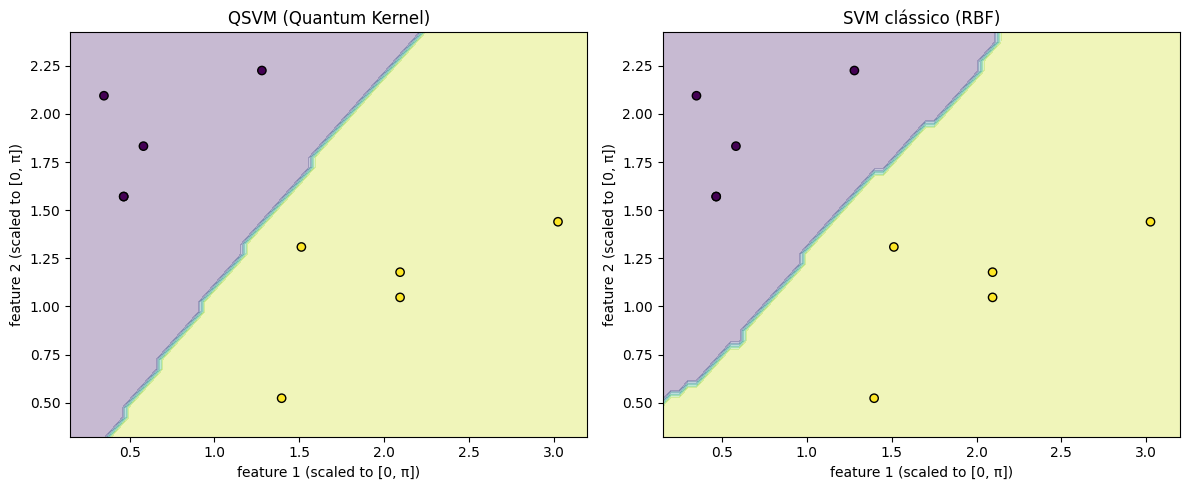

In [ ]:
# ----------------------------
# Comparação com SVM clássico (RBF)
# ----------------------------
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
print("Acurácia SVM clássico (RBF):", accuracy_score(y_test, y_pred_rbf))
# ----------------------------
# 4) Plots: fronteira de decisão
# ----------------------------
def plot_decision_boundary_precomputed_kernel(
    model, X_train, y_train, kernel_func, title, h=0.05
):
    """
    Plota a fronteira de decisão para modelos com kernel precomputado.
    Para cada ponto do grid, calcula K(grid, X_train) e aplica model.predict.
    """
    x_min, x_max = X_train[:, 0].min() - 0.2, X_train[:, 0].max() + 0.2
    y_min, y_max = X_train[:, 1].min() - 0.2, X_train[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Kernel entre grid e pontos de treino
    K_grid = kernel_func(grid, X_train)

    # Predição
    Z = model.predict(K_grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k")
    plt.title(title)
    plt.xlabel("feature 1 (scaled to [0, π])")
    plt.ylabel("feature 2 (scaled to [0, π])")

def plot_decision_boundary_standard(model, X, y, title, h=0.05):
    """
    Plota a fronteira de decisão para modelos clássicos padrão.
    """
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title(title)
    plt.xlabel("feature 1 (scaled to [0, π])")
    plt.ylabel("feature 2 (scaled to [0, π])")


# ----------------------------
# Plot fronteiras: QSVM vs SVM clássico
# ----------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary_precomputed_kernel(
    qsvm,
    X_train,
    y_train,
    quantum_kernel_matrix,
    "QSVM (Quantum Kernel)"
)

plt.subplot(1, 2, 2)
plot_decision_boundary_standard(
    svm_rbf,
    X_train,
    y_train,
    "SVM clássico (RBF)"
)

plt.tight_layout()
plt.show()



## 2.3 - VQC

O **VQC (Variational Quantum Classifier)** é um classificador quântico baseado
em **circuitos variacionais**, no qual a decisão é obtida a partir do valor
esperado de observáveis quânticos após a aplicação de um circuito treinável.
Diferentemente do QSVM, que depende de um kernel quântico pré-computado, o VQC
aprende diretamente uma **fronteira de decisão parametrizada** por meio de
otimização variacional.

Dado um vetor clássico $\mathbf{x}$, ele é codificado em um estado quântico por
meio de um *feature map* quântico:

$$
|\phi(\mathbf{x})\rangle = S(\mathbf{x})|0\ldots 0\rangle.
$$

Após a codificação dos dados, aplica-se um circuito variacional
$U(\boldsymbol{\theta})$, cujos parâmetros são ajustados durante o treinamento.
O estado final do circuito é então medido por meio de um observável quântico
$\hat{O}$, produzindo um valor esperado que funciona como **score do
classificador**:

$$
f(\mathbf{x}; \boldsymbol{\theta})
=
\langle \phi(\mathbf{x}) |
U^\dagger(\boldsymbol{\theta}) \, \hat{O} \, U(\boldsymbol{\theta})
| \phi(\mathbf{x}) \rangle.
$$

A classificação é realizada a partir do sinal (ou limiar) desse valor esperado,
enquanto os parâmetros $\boldsymbol{\theta}$ são treinados minimizando uma
função de custo clássica. Assim, o VQC constitui um modelo **híbrido
clássico–quântico**, no qual a parte quântica atua como um modelo parametrizado
e a parte clássica realiza a otimização.


### 2.3.1 - Dataset
Utilizamos o conjunto Iris em uma versão binária (classes 0 e 1), com apenas duas features por amostra, permitindo codificação direta em dois qubits.

In [ ]:
# ----------------------------
# 1) Dataset Iris (binário)
# ----------------------------
iris = load_iris()

# Seleciona apenas duas features (compatível com 2 qubits)
X = iris.data[:, :2]
y = iris.target

# Mantém apenas classes 0 e 1
mask = y < 2
X = X[mask]
y = y[mask]

# Converte rótulos para {-1, +1}, adequado à saída do observável
y = 2*y - 1

# Escala os dados para [0, pi] (ângulos de rotação)
scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

# Conjunto de treino pequeno (exemplo didático)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=10, stratify=y, random_state=0
)

### 2.3.2 - Feature map + Circuito variacional
Cada vetor clássico $\mathbf{x}$ é codificado em um estado quântico por meio de *Angle Encoding*,
$$|\phi(\mathbf{x})\rangle = S(\mathbf{x})|00\rangle.$$
Após o feature map, aplicamos uma unidade variacional
   $U(\boldsymbol{\theta})$ composta por rotações parametrizadas e portas CNOT.
A saída do modelo é o valor esperado de um observável de Pauli,
   utilizado como função de decisão do classificador.

In [ ]:
# ----------------------------
# 2) Dispositivo quântico
# ----------------------------
n = 2
dev = qml.device("default.qubit", wires=n)


# ----------------------------
# 3) Unidade variacional U(theta)
# ----------------------------
# Camada treinável composta por rotações e emaranhamento
def U(theta):
    qml.RY(theta[0], wires=0)
    qml.RY(theta[1], wires=1)

    qml.CNOT(wires=[0, 1])

    qml.RY(theta[2], wires=0)
    qml.RY(theta[3], wires=1)

    qml.CNOT(wires=[1, 0])

# ----------------------------
# 4) Circuito quântico variacional
# ----------------------------
# Aplica o feature map seguido da unidade variacional
# A saída é um valor esperado, interpretado como score do classificador
@qml.qnode(dev, diff_method="parameter-shift")
def circuit(x, theta):
    S(x)
    U(theta)
    return qml.expval(qml.PauliZ(0) + qml.PauliZ(1))

### 2.3.3 - Treinamento
Os parâmetros $\boldsymbol{\theta}$ são otimizados via métodos de gradiente (parameter-shift), minimizando o erro quadrático médio entre as predições e os rótulos verdadeiros.

In [ ]:
from pennylane import numpy as np


# ----------------------------
# 5) Função de custo (loss)
# ----------------------------
# Erro quadrático médio entre rótulos e predições
def loss(theta, X, y):
    preds = np.stack([circuit(x, theta) for x in X])
    return np.mean((y - preds) ** 2)

# ----------------------------
# 6) Treinamento variacional
# ----------------------------
opt = qml.AdamOptimizer(stepsize=0.1)

# Inicializa parâmetros treináveis
theta = np.random.uniform(0, 2*np.pi, size=4, requires_grad=True)

loss_history = []

for it in range(100):
    theta = opt.step(lambda t: loss(t, X_train, y_train), theta)
    L = loss(theta, X_train, y_train)
    loss_history.append(L)

    if it % 10 == 0:
        print(f"Iter {it:2d} | Loss = {L:.4f}")

Iter  0 | Loss = 1.4316
Iter 10 | Loss = 0.6108
Iter 20 | Loss = 0.5598
Iter 30 | Loss = 0.1924
Iter 40 | Loss = 0.1897
Iter 50 | Loss = 0.1744
Iter 60 | Loss = 0.1672
Iter 70 | Loss = 0.1636
Iter 80 | Loss = 0.1633
Iter 90 | Loss = 0.1628


### 2.3.4 - Avaliação
O desempenho do VQC é avaliado no conjunto de teste e comparado com um classificador clássico de regressão logística.

Acurácia VQC: 1.0


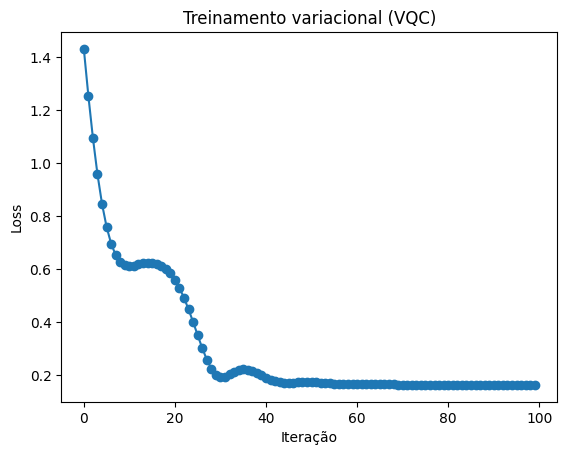

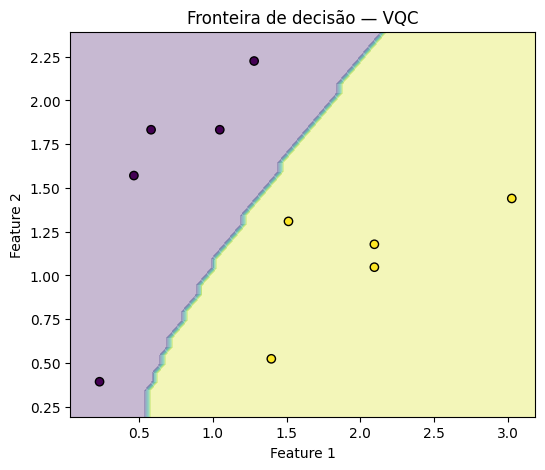

Acurácia logística clássica: 0.9444444444444444


In [ ]:
# ----------------------------
# 8) Predição e avaliação
# ----------------------------
def predict(X, theta):
    # Classificação pelo sinal da saída do circuito
    y_pred = np.sign([circuit(x, theta) for x in X])
    return y_pred

y_pred_test = predict(X_test, theta)
acc = accuracy_score(y_test, y_pred_test)

print("Acurácia VQC:", acc)

# ----------------------------
# 9) Curva de treinamento
# ----------------------------
plt.figure()
plt.plot(loss_history, marker="o")
plt.xlabel("Iteração")
plt.ylabel("Loss")
plt.title("Treinamento variacional (VQC)")
plt.show()

# ----------------------------
# 10) Fronteira de decisão do VQC
# ----------------------------
def plot_vqc_boundary(X, y, theta):
    h = 0.05
    x_min, x_max = X[:,0].min()-0.2, X[:,0].max()+0.2
    y_min, y_max = X[:,1].min()-0.2, X[:,1].max()+0.2

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.sign([circuit(p, theta) for p in grid])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors="k")
    plt.title("Fronteira de decisão — VQC")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.figure(figsize=(6,5))
plot_vqc_boundary(X_train, y_train, theta)
plt.show()

# ----------------------------
# 11) Comparação com classificador clássico
# ----------------------------
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)

acc_cl = clf.score(X_test, y_test)
print("Acurácia logística clássica:", acc_cl)

# 3 - Algoritmos Nâo-Supervisionados

## 3.1 - Quantum k-Means
O **Quantum k-Means** é a versão quântica–híbrida do algoritmo clássico de
agrupamento k-means, na qual a noção de proximidade entre pontos não é definida
por uma distância Euclidiana, mas por uma **similaridade quântica** entre estados
codificados.

A ideia central é utilizar um circuito quântico apenas para mapear dados
clássicos em estados quânticos e medir o quanto esses estados são semelhantes
no espaço de Hilbert. A lógica global do algoritmo, atribuição a clusters e
atualização de centróides, permanece a mesma do k-means clássico.

Dado um ponto clássico $\mathbf{x}$, ele é codificado em um estado quântico por
meio de um *feature map* quântico:

$$
|\phi(\mathbf{x})\rangle = S(\mathbf{x})|0\ldots 0\rangle.
$$

A similaridade entre dois pontos $\mathbf{x}$ e $\mathbf{y}$ é então definida
pela **fidelidade entre os estados quânticos correspondentes**:

$$
\text{sim}(\mathbf{x},\mathbf{y})
=
\left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{y}) \rangle\right|^2.
$$

Essa quantidade mede o quanto dois pontos estão próximos **no espaço quântico**
e substitui diretamente a distância clássica utilizada no k-means tradicional.
Assim, o agrupamento passa a ser guiado pela geometria induzida pelo feature map
quântico.

Diferentemente do QSVM e do VQC, o Quantum k-Means não envolve treinamento por
gradiente. O algoritmo alterna iterativamente entre atribuição de pontos aos
clusters e atualização clássica dos centróides, caracterizando um método
**híbrido clássico–quântico**.


### 3.1.1 - Feature map + Similaridade Quântica
Cada ponto clássico $\mathbf{x}\in\mathbb{R}^2$ é codificado
   em um estado quântico
   $$
   |\phi(\mathbf{x})\rangle = S(\mathbf{x})|00\rangle
   $$
   usando *Angle Encoding*.

A proximidade entre dois pontos $\mathbf{x}$ e  $\mathbf{y}$ é medida pela fidelidade $$\text{sim}(\mathbf{x},\mathbf{y})
   = \left|\langle \phi(\mathbf{x}) \mid \phi(\mathbf{y}) \rangle\right|^2.
   $$
   No circuito, essa fidelidade é obtida aplicando $S(\mathbf{x})$ seguido de
   $S^\dagger(\mathbf{y})$ e medindo a probabilidade de observar $|00\rangle$.

In [ ]:
# ----------------------------
# 1) Dataset sintético
# ----------------------------
# Usamos make_blobs para gerar um dataset com 2 clusters bem definidos,
# mais limpo que o Iris para demonstrar clustering.
X, _ = make_blobs(
    n_samples=10,
    centers=2,
    cluster_std=0.8,
    random_state=0
)

# Escalamos para [0, pi] porque vamos usar os valores como ângulos no embedding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

# ----------------------------
# 2) Dispositivo quântico e feature map
# ----------------------------
n = 2
dev = qml.device("default.qubit", wires=n)

# ----------------------------
# 3) Fidelidade (similaridade quântica)
# ----------------------------
# Option A:
# - prepara |phi(x)> aplicando S(x)
# - aplica S†(y)
# - mede P(|00>) = |<phi(x)|phi(y)>|^2
@qml.qnode(dev)
def fidelity(x, y):
    S(x)
    qml.adjoint(S)(y)
    probs = qml.probs(wires=range(n))
    return probs   # probs[0] = fidelidade

### 3.1.2 - Atribuição + Atualização

O resultado é um método híbrido: o circuito fornece uma noção de proximidade
no espaço de Hilbert e a atualização dos centróides permanece clássica.
A cada ponto é atribuído ao centróide com maior similaridade.

Os centróides são atualizados de forma clássica, usando a média dos pontos atribuídos (isto mantém o algoritmo simples e estável).

In [ ]:
# ----------------------------
# 4) Quantum k-means
# ----------------------------
def quantum_kmeans(X, k=2, max_iter=10):
    # Inicializa centróides (no espaço clássico) escolhendo pontos aleatórios
    centroids = X[np.random.choice(len(X), k, replace=False)]

    for _ in range(max_iter):
        # Lista de clusters: cada cluster será uma lista de pontos x
        clusters = [[] for _ in range(k)]

        # --- Atribuição ---
        # Para cada ponto x, calculamos a similaridade quântica com cada centróide
        # e o atribuimos ao centróide com maior fidelidade.
        for x in X:
            sims = [fidelity(x, c)[0] for c in centroids]  # similaridades
            j = int(np.argmax(sims))                      # cluster "mais próximo"
            clusters[j].append(x)

        # --- Atualização ---
        # Atualiza os centróides como a média clássica dos pontos do cluster.
        new_centroids = []
        for j in range(k):
            if len(clusters[j]) == 0:
                # Se um cluster ficar vazio, mantemos o centróide anterior
                new_centroids.append(centroids[j])
            else:
                # Média clássica no espaço original (ainda escalado)
                new_centroids.append(np.mean(clusters[j], axis=0))

        centroids = np.array(new_centroids)

    return centroids, clusters

# Executa o quantum k-means
centroids, clusters = quantum_kmeans(X, k=2)


## 3.1.3 - Comparação com o clássico


=== Avaliação ===
k-means clássico | Inércia = 7.4533 | Silhouette = 0.5520
Quantum k-means  | Inércia = 17.2078 | Silhouette = 0.2481


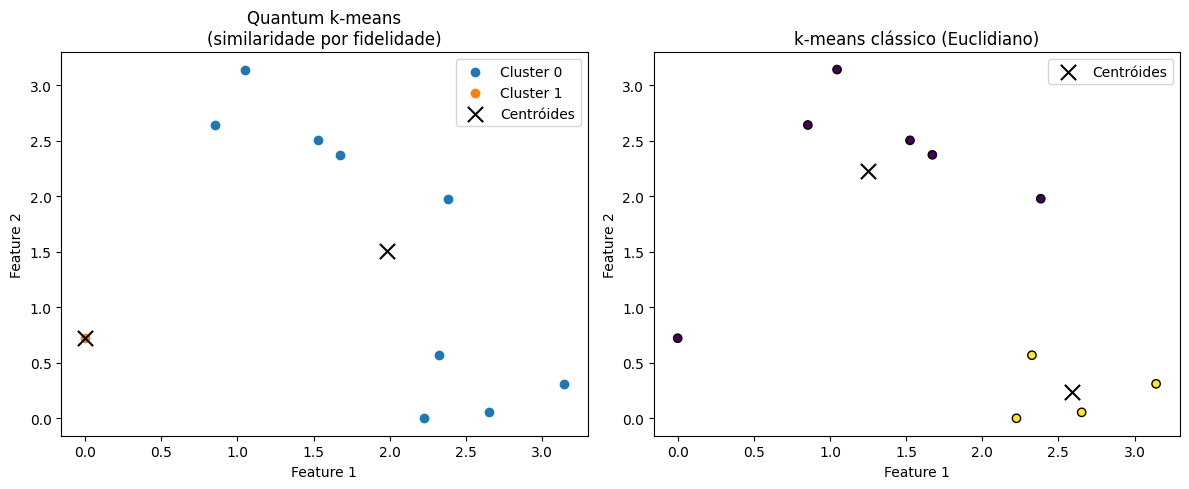

In [ ]:
# ----------------------------
# 6) k-means clássico
# ----------------------------
k = 2
kmeans_cl = KMeans(n_clusters=k, n_init=10, random_state=0)
labels_cl = kmeans_cl.fit_predict(X)

centroids_cl = kmeans_cl.cluster_centers_

# ----------------------------
# 7) Avaliação quantitativa
# ----------------------------

# --- Quantum k-means ---
# Constrói rótulos a partir da lista de clusters
labels_q = np.zeros(len(X), dtype=int)
for j, cluster in enumerate(clusters):
    for x in cluster:
        idx = np.where((X == x).all(axis=1))[0][0]
        labels_q[idx] = j

inertia_cl = kmeans_cl.inertia_
silhouette_cl = silhouette_score(X, labels_cl)

# Para o quantum k-means, usamos as mesmas métricas clássicas
# (avaliadas no espaço original dos dados)
inertia_q = np.sum([
    np.sum((np.array(cluster) - centroids[j])**2)
    for j, cluster in enumerate(clusters)
])

silhouette_q = silhouette_score(X, labels_q)

print("=== Avaliação ===")
print(f"k-means clássico | Inércia = {inertia_cl:.4f} | Silhouette = {silhouette_cl:.4f}")
print(f"Quantum k-means  | Inércia = {inertia_q:.4f} | Silhouette = {silhouette_q:.4f}")

# ----------------------------
# 8) Plots: Quantum vs Clássico
# ----------------------------
plt.figure(figsize=(12, 5))

# --- Quantum k-means ---
plt.subplot(1, 2, 1)
for j, cluster in enumerate(clusters):
    cluster = np.array(cluster)
    plt.scatter(cluster[:, 0], cluster[:, 1], label=f"Cluster {j}")

plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c="black", marker="x", s=120, label="Centróides"
)

plt.title("Quantum k-means\n(similaridade por fidelidade)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# --- k-means clássico ---
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_cl, edgecolors="k")
plt.scatter(
    centroids_cl[:, 0], centroids_cl[:, 1],
    c="black", marker="x", s=120, label="Centróides"
)

plt.title("k-means clássico (Euclidiano)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.tight_layout()
plt.show()
